# Conjura MMM Data: Holistic PyMC Marketing Analysis

This notebook turns `conjura_mmm_data.csv` into a practical MMM workflow: series selection, daily-to-weekly aggregation, EDA, baseline/seasonality thinking, PyMC Marketing modeling, diagnostics, contribution, ROAS, and stakeholder interpretation.

Important: the CSV contains many organizations/time series. A standard MMM should usually model one clean time series first. This notebook defaults to the longest `MMM_TIMESERIES_ID`, but you can change that choice in Section 2.

## 0. Setup

This notebook is configured for Google Colab using a mounted Google Drive. Upload `conjura_mmm_data.csv` to your Drive, run the mount cell, then set `DRIVE_DATA_PATH` to the copied file path. The PyMC sampling section can take several minutes.


In [1]:
#%pip install -U pymc-marketing arviz statsmodels scikit-learn seaborn

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

# Colab / Google Drive setup.
# 1. Upload conjura_mmm_data.csv to Google Drive, for example: MyDrive/mmm/conjura_mmm_data.csv
# 2. Mount Drive.
# 3. Set DRIVE_DATA_PATH to the exact path shown in Colab's file browser.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError:
    print("Not running in Google Colab; using local fallback path.")

DRIVE_DATA_PATH = Path("/content/drive/MyDrive/conjura_mmm_data.csv")
LOCAL_FALLBACK_PATH = Path("conjura_mmm_data.csv")

if DRIVE_DATA_PATH.exists():
    DATA_PATH = DRIVE_DATA_PATH
elif LOCAL_FALLBACK_PATH.exists():
    DATA_PATH = LOCAL_FALLBACK_PATH
else:
    raise FileNotFoundError(
        "Could not find conjura_mmm_data.csv. In Colab, upload it to Drive and update DRIVE_DATA_PATH. "
        "You can locate it with: !find /content/drive/MyDrive -name 'conjura_mmm_data.csv'"
    )

print("Using data file:", DATA_PATH)
RANDOM_SEED = 42


Not running in Google Colab; using local fallback path.


FileNotFoundError: Could not find conjura_mmm_data.csv. In Colab, upload it to Drive and update DRIVE_DATA_PATH. You can locate it with: !find /content/drive/MyDrive -name 'conjura_mmm_data.csv'

## 1. Load And Audit

The file is daily and panel-like: many `MMM_TIMESERIES_ID` values. We first inspect coverage, missingness, and candidate targets/media fields.

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["DATE_DAY"] = pd.to_datetime(df_raw["DATE_DAY"])

numeric_like = [
    c for c in df_raw.columns
    if c.endswith(("SPEND", "CLICKS", "IMPRESSIONS"))
    or c in [
        "FIRST_PURCHASES", "FIRST_PURCHASES_UNITS", "FIRST_PURCHASES_ORIGINAL_PRICE", "FIRST_PURCHASES_GROSS_DISCOUNT",
        "ALL_PURCHASES", "ALL_PURCHASES_UNITS", "ALL_PURCHASES_ORIGINAL_PRICE", "ALL_PURCHASES_GROSS_DISCOUNT",
    ]
]
for c in numeric_like:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

print("Shape:", df_raw.shape)
print("Date range:", df_raw["DATE_DAY"].min(), "to", df_raw["DATE_DAY"].max())
print("Unique time series:", df_raw["MMM_TIMESERIES_ID"].nunique())
print("Unique organizations:", df_raw["ORGANISATION_ID"].nunique())
display(df_raw.head())
display(df_raw.isna().mean().sort_values(ascending=False).to_frame("missing_rate").head(25))

Shape: (132759, 50)
Date range: 2019-07-21 00:00:00 to 2024-06-02 00:00:00
Unique time series: 143
Unique organizations: 93


,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,GOOGLE_PAID_SEARCH_CLICKS,GOOGLE_SHOPPING_CLICKS,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_DISPLAY_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-29,USD,22,27,3837.980834,632.595555,27,32,4552.984240,846.593069,NaN,NaN,205.528905,NaN,NaN,233.75,NaN,NaN,NaN,NaN,NaN,255.0,NaN,NaN,163.0,NaN,NaN,NaN,NaN,NaN,31907.0,NaN,NaN,18997.0,NaN,NaN,NaN,139.0,NaN,300.0,1.0,61.0,40.0
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-30,USD,14,21,2747.998631,443.996522,17,26,3177.998032,613.806522,NaN,NaN,277.082025,NaN,NaN,248.84,NaN,NaN,NaN,NaN,NaN,348.0,NaN,NaN,128.0,NaN,NaN,NaN,NaN,NaN,44483.0,NaN,NaN,20188.0,NaN,NaN,NaN,209.0,NaN,442.0,8.0,110.0,62.0
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-31,USD,31,39,4567.998818,1185.197966,39,48,5468.998818,1504.997966,NaN,NaN,427.436429,NaN,NaN,274.51,NaN,NaN,NaN,NaN,NaN,405.0,NaN,NaN,148.0,NaN,NaN,NaN,NaN,NaN,58173.0,NaN,NaN,24718.0,NaN,NaN,NaN,262.0,NaN,427.0,631.0,108.0,65.0
3,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-01,USD,18,30,2878.982385,696.519993,22,34,3335.970202,754.410747,35.24,NaN,347.232798,NaN,NaN,270.06,NaN,NaN,NaN,48.0,NaN,320.0,NaN,NaN,163.0,NaN,NaN,NaN,890.0,NaN,55559.0,NaN,NaN,25076.0,NaN,NaN,NaN,247.0,NaN,400.0,117.0,125.0,68.0
4,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-02,USD,23,27,3107.993669,627.097427,28,33,3991.987441,934.011083,38.40,NaN,314.952971,NaN,NaN,257.62,NaN,NaN,NaN,46.0,NaN,330.0,NaN,NaN,127.0,NaN,NaN,NaN,702.0,NaN,47854.0,NaN,NaN,22688.0,NaN,NaN,NaN,255.0,NaN,425.0,37.0,146.0,65.0


,missing_rate
TIKTOK_CLICKS,0.973923
TIKTOK_SPEND,0.973923
TIKTOK_IMPRESSIONS,0.973923
GOOGLE_VIDEO_SPEND,0.942543
GOOGLE_VIDEO_IMPRESSIONS,0.942543
GOOGLE_VIDEO_CLICKS,0.942543
GOOGLE_DISPLAY_SPEND,0.858797
GOOGLE_DISPLAY_CLICKS,0.858797
GOOGLE_DISPLAY_IMPRESSIONS,0.858797
META_OTHER_CLICKS,0.822649


## 2. Select One Time Series

The data dictionary says `mmm_timeseries_id` is the unique identifier for a single MMM time series. Start with one time series. Do **not** aggregate multiple `MMM_TIMESERIES_ID` values unless you intentionally handle currency conversion and territory logic.

This section prefers a usable `All Territories` series with both revenue and paid media activity. A long series with zero spend is not useful for MMM because there is no media variation to estimate. If your business question is territory-specific, manually set `SELECTED_SERIES_ID` to that territory's time series.


In [ ]:
spend_cols_raw = [
    "GOOGLE_PAID_SEARCH_SPEND", "GOOGLE_SHOPPING_SPEND", "GOOGLE_PMAX_SPEND",
    "GOOGLE_DISPLAY_SPEND", "GOOGLE_VIDEO_SPEND",
    "META_FACEBOOK_SPEND", "META_INSTAGRAM_SPEND", "META_OTHER_SPEND", "TIKTOK_SPEND",
]

df_for_selection = df_raw.assign(
    total_spend=df_raw[spend_cols_raw].fillna(0).sum(axis=1),
    has_paid_spend=df_raw[spend_cols_raw].fillna(0).sum(axis=1).gt(0).astype(int),
    has_revenue=df_raw["ALL_PURCHASES_ORIGINAL_PRICE"].fillna(0).gt(0).astype(int),
)

series_summary = (
    df_for_selection
    .groupby("MMM_TIMESERIES_ID")
    .agg(
        rows=("DATE_DAY", "size"),
        start=("DATE_DAY", "min"),
        end=("DATE_DAY", "max"),
        organisation_id=("ORGANISATION_ID", "first"),
        vertical=("ORGANISATION_VERTICAL", "first"),
        subvertical=("ORGANISATION_SUBVERTICAL", "first"),
        primary_territory=("ORGANISATION_PRIMARY_TERRITORY_NAME", "first"),
        territory=("TERRITORY_NAME", "first"),
        currency=("CURRENCY_CODE", "first"),
        sources=("ORGANISATION_MARKETING_SOURCES", "first"),
        total_spend=("total_spend", "sum"),
        spend_active_days=("has_paid_spend", "sum"),
        revenue_active_days=("has_revenue", "sum"),
        all_revenue=("ALL_PURCHASES_ORIGINAL_PRICE", "sum"),
        first_revenue=("FIRST_PURCHASES_ORIGINAL_PRICE", "sum"),
    )
)
series_summary["duration_days"] = (series_summary["end"] - series_summary["start"]).dt.days + 1
series_summary["spend_active_rate"] = series_summary["spend_active_days"] / series_summary["rows"]
series_summary["revenue_active_rate"] = series_summary["revenue_active_days"] / series_summary["rows"]
series_summary = series_summary.sort_values(
    ["total_spend", "all_revenue", "rows"], ascending=False
)

display(series_summary.head(20))

usable = series_summary[
    (series_summary["rows"] >= 449)
    & (series_summary["total_spend"] > 0)
    & (series_summary["all_revenue"] > 0)
    & (series_summary["spend_active_days"] >= 30)
]
all_territories_usable = usable[usable["territory"].str.lower().eq("all territories")]

if len(all_territories_usable) > 0:
    SELECTED_SERIES_ID = all_territories_usable.index[0]
elif len(usable) > 0:
    SELECTED_SERIES_ID = usable.index[0]
else:
    raise ValueError("No usable time series found with revenue and enough paid spend activity. Lower the thresholds or inspect series_summary.")

# To override, paste a specific id here, for example:
# SELECTED_SERIES_ID = "596eef7c71f933d820d0e485935d0e8f"

print("Selected:", SELECTED_SERIES_ID)
display(series_summary.loc[[SELECTED_SERIES_ID]])

daily = df_raw[df_raw["MMM_TIMESERIES_ID"] == SELECTED_SERIES_ID].copy()
daily = daily.sort_values("DATE_DAY").reset_index(drop=True)

print("Currencies in selected series:", daily["CURRENCY_CODE"].unique())
print("Territories in selected series:", daily["TERRITORY_NAME"].unique())
print("Date coverage:", daily["DATE_DAY"].min(), "to", daily["DATE_DAY"].max(), "rows=", len(daily))
display(daily.head())


,rows,start,end,organisation_id,vertical,subvertical,primary_territory,territory,currency,sources,total_spend,spend_active_days,revenue_active_days,all_revenue,first_revenue,duration_days,spend_active_rate,revenue_active_rate
MMM_TIMESERIES_ID,,,,,,,,,,,,,,,,,,
6bbe4be7e89e1f928c22abdb66b405da,923,2021-11-23,2024-06-02,5488b06e575cc0e13be2cd67325ffa33,Apparel,Other,Chile,All Territories,CLP,"Google, Meta",9.689299e+08,923,923,8.016025e+09,3.998696e+09,923,1.000000,1.0
6be017619bfb9354aaa747f6c2dca447,1415,2020-04-21,2024-03-05,784d6aa3cda59f59f2400332b2420a49,Apparel,Women's Clothing,UK,All Territories,GBP,"Google, Meta",1.347350e+07,1415,1415,6.765982e+07,3.608917e+07,1415,1.000000,1.0
cb7a6b47ef907adfb0c7f1922392225d,794,2021-10-17,2023-12-19,0e2793fc272def8aa56ece30bab692dd,Health,Nutrition,Japan,All Territories,JPY,Google,1.197867e+07,690,794,4.768785e+09,2.411500e+09,794,0.869018,1.0
cf96248a058cd86dd968c91b294a31fd,571,2022-10-28,2024-05-20,c5fbe353800204351f2768f90d703b38,Apparel,Other,Denmark,All Territories,DKK,"Google, Meta",9.783861e+06,571,571,5.933660e+07,4.548034e+07,571,1.000000,1.0
c6a5d39d2b6ea6a6b36bd230cb6fd7ac,1276,2020-11-21,2024-05-19,df208255d3c8eea8d60fb4ae697d20de,Beauty & Fitness,Face & Body Care,US,All Territories,USD,"Google, Meta",9.071030e+06,1276,1276,3.008405e+07,2.493988e+07,1276,1.000000,1.0
ac9965a4cc73306fa9e4fcc0ac581eb5,821,2021-10-15,2024-01-13,7569a6a9c156a0f9398fa6cfd51df5bb,Food & Drink,Other,US,All Territories,USD,"Google, Meta, Tiktok",9.045384e+06,821,821,3.036897e+07,1.894888e+07,821,1.000000,1.0
513211a5ba7d7c20145586b16abfda54,821,2021-10-15,2024-01-13,7569a6a9c156a0f9398fa6cfd51df5bb,Food & Drink,Other,US,US,USD,"Google, Meta, Tiktok",8.184572e+06,821,821,2.478289e+07,1.547219e+07,821,1.000000,1.0
6b89cf94d2e23372be3846ed656b5e47,1389,2020-04-21,2024-02-08,784d6aa3cda59f59f2400332b2420a49,Apparel,Women's Clothing,UK,UK,GBP,"Google, Meta",8.140192e+06,1389,1389,4.359866e+07,2.199174e+07,1389,1.000000,1.0
51c8843bddcc604ebb3fe8d638ee5a1d,1610,2020-01-06,2024-06-02,ba773ebd7ec0a08f1d042187d086ccb4,Business & Industrial,Business Services,UK,All Territories,GBP,"Google, Meta",7.687312e+06,1610,1610,2.486787e+08,1.980342e+08,1610,1.000000,1.0


Selected: 6bbe4be7e89e1f928c22abdb66b405da


,rows,start,end,organisation_id,vertical,subvertical,primary_territory,territory,currency,sources,total_spend,spend_active_days,revenue_active_days,all_revenue,first_revenue,duration_days,spend_active_rate,revenue_active_rate
MMM_TIMESERIES_ID,,,,,,,,,,,,,,,,,,
6bbe4be7e89e1f928c22abdb66b405da,923,2021-11-23,2024-06-02,5488b06e575cc0e13be2cd67325ffa33,Apparel,Other,Chile,All Territories,CLP,"Google, Meta",9.689299e+08,923,923,8.016025e+09,3.998696e+09,923,1.0,1.0


Currencies in selected series: ['CLP']
Territories in selected series: ['All Territories']
Date coverage: 2021-11-23 00:00:00 to 2024-06-02 00:00:00 rows= 923


,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,GOOGLE_PAID_SEARCH_CLICKS,GOOGLE_SHOPPING_CLICKS,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_DISPLAY_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,6bbe4be7e89e1f928c22abdb66b405da,5488b06e575cc0e13be2cd67325ffa33,Apparel,Other,"Google, Meta",Chile,All Territories,2021-11-23,CLP,64,129,2606710.0,10994.0,93,180,3841200.0,155435.0,12758.0,17360.89,NaN,6262.24,11574.92,468799.62,3654.43,13.98,NaN,124.0,341.0,NaN,24.0,12.0,4043.0,9.0,0.0,NaN,471.0,35914.0,NaN,7989.0,2982.0,435523.0,1014.0,7.0,NaN,676.0,637.0,274.0,64.0,32.0,2358.0
1,6bbe4be7e89e1f928c22abdb66b405da,5488b06e575cc0e13be2cd67325ffa33,Apparel,Other,"Google, Meta",Chile,All Territories,2021-11-24,CLP,88,161,3244390.0,124736.0,126,248,5039526.0,332646.0,16148.0,13323.79,NaN,5228.02,11392.46,313296.02,3800.00,7.00,NaN,133.0,324.0,NaN,15.0,8.0,2723.0,8.0,0.0,NaN,467.0,46781.0,NaN,5139.0,3017.0,333405.0,1066.0,4.0,NaN,695.0,689.0,286.0,72.0,47.0,1939.0
2,6bbe4be7e89e1f928c22abdb66b405da,5488b06e575cc0e13be2cd67325ffa33,Apparel,Other,"Google, Meta",Chile,All Territories,2021-11-25,CLP,71,111,2260890.0,47876.0,111,198,3979020.0,188613.0,12878.0,14890.22,NaN,5038.32,9964.10,294787.01,3913.00,11.00,NaN,124.0,333.0,NaN,26.0,12.0,2572.0,16.0,0.0,NaN,493.0,52050.0,NaN,8368.0,2562.0,289959.0,990.0,4.0,NaN,1045.0,785.0,286.0,111.0,44.0,2008.0
3,6bbe4be7e89e1f928c22abdb66b405da,5488b06e575cc0e13be2cd67325ffa33,Apparel,Other,"Google, Meta",Chile,All Territories,2021-11-26,CLP,123,232,4825680.0,104948.0,176,327,6856730.0,222005.0,20573.0,17722.62,NaN,5375.69,9789.54,293037.81,5130.19,4.00,NaN,150.0,342.0,NaN,4.0,8.0,2232.0,9.0,0.0,NaN,541.0,51241.0,NaN,751.0,2429.0,259452.0,1179.0,1.0,NaN,874.0,1212.0,386.0,71.0,36.0,2522.0
4,6bbe4be7e89e1f928c22abdb66b405da,5488b06e575cc0e13be2cd67325ffa33,Apparel,Other,"Google, Meta",Chile,All Territories,2021-11-27,CLP,76,139,2986610.0,35092.0,119,234,4905660.0,183412.0,22623.0,16670.32,NaN,5097.37,10020.41,288634.01,4754.00,41.00,NaN,135.0,301.0,NaN,8.0,10.0,2234.0,16.0,0.0,NaN,494.0,39945.0,NaN,1997.0,2513.0,257770.0,1119.0,13.0,NaN,584.0,736.0,266.0,32.0,20.0,2079.0


## 3. Aggregate Daily Data To Weekly

MMM is usually more stable at weekly granularity. We aggregate purchases, revenue, spend, clicks, and impressions by week starting Monday.

In [ ]:
# Monday week start. Avoid W-MON period start_time because W-MON periods end on Monday and start on Tuesday.
daily["week"] = daily["DATE_DAY"] - pd.to_timedelta(daily["DATE_DAY"].dt.weekday, unit="D")
daily["week"] = daily["week"].dt.normalize()

target_cols = [
    "FIRST_PURCHASES", "FIRST_PURCHASES_UNITS", "FIRST_PURCHASES_ORIGINAL_PRICE", "FIRST_PURCHASES_GROSS_DISCOUNT",
    "ALL_PURCHASES", "ALL_PURCHASES_UNITS", "ALL_PURCHASES_ORIGINAL_PRICE", "ALL_PURCHASES_GROSS_DISCOUNT",
]
click_cols = [c for c in daily.columns if c.endswith("CLICKS")]
impression_cols = [c for c in daily.columns if c.endswith("IMPRESSIONS")]

sum_cols = target_cols + spend_cols_raw + click_cols + impression_cols
weekly = daily.groupby("week", as_index=False)[sum_cols].sum(min_count=1)
weekly[sum_cols] = weekly[sum_cols].fillna(0)

print("Weekly totals before filling missing calendar weeks:")
display(weekly[["week"] + sum_cols[:4] + spend_cols_raw].head())
print("Total paid spend before calendar fill:", weekly[spend_cols_raw].sum().sum())

# Fill missing weeks explicitly.
full_weeks = pd.DataFrame({"week": pd.date_range(weekly["week"].min(), weekly["week"].max(), freq="W-MON")})
weekly = full_weeks.merge(weekly, on="week", how="left")
weekly[sum_cols] = weekly[sum_cols].fillna(0)

print("Total paid spend after calendar fill:", weekly[spend_cols_raw].sum().sum())
print("Weekly shape:", weekly.shape)
print("Weekly date range:", weekly["week"].min(), "to", weekly["week"].max())
display(weekly.head())

Weekly totals before filling missing calendar weeks:


,week,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND
0,2021-11-22,517,955,19473450.0,403893.0,103209.0,102361.23,0.00,31252.03,62702.59,1951331.49,26325.62,107.98,0.0
1,2021-11-29,858,1516,30739845.0,499668.0,123874.0,110542.87,0.00,34497.32,67088.60,2552948.36,43404.70,37.00,0.0
2,2021-12-06,1045,1700,34865010.0,702880.0,184649.0,208380.09,0.00,35810.73,68872.77,3211857.98,49801.78,9.17,0.0
3,2021-12-13,1427,2259,46135430.0,930019.0,135479.0,121777.11,11267.17,36045.36,53806.13,3526830.40,49964.03,37.59,0.0
4,2021-12-20,1247,2038,40091708.0,1154702.0,115653.0,18202.12,48006.43,29336.38,65441.66,5633129.28,50794.72,7.00,0.0


Total paid spend before calendar fill: 968929871.2025508
Total paid spend after calendar fill: 968929871.2025508
Weekly shape: (132, 42)
Weekly date range: 2021-11-22 00:00:00 to 2024-05-27 00:00:00


,week,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,GOOGLE_PAID_SEARCH_CLICKS,GOOGLE_SHOPPING_CLICKS,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_DISPLAY_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS
0,2021-11-22,517,955,19473450.0,403893.0,762,1456,29963446.0,1264321.0,103209.0,102361.23,0.00,31252.03,62702.59,1951331.49,26325.62,107.98,0.0,797.0,2043.0,0.0,99.0,58.0,16246.0,75.0,0.0,0.0,4533.0,4976.0,1839.0,376.0,202.0,13105.0,3060.0,279992.0,0.0,30292.0,15969.0,1859727.0,6595.0,38.0,0.0
1,2021-11-29,858,1516,30739845.0,499668.0,1280,2323,48459984.0,1634285.0,123874.0,110542.87,0.00,34497.32,67088.60,2552948.36,43404.70,37.00,0.0,1156.0,2650.0,0.0,134.0,63.0,24556.0,191.0,0.0,0.0,6073.0,6030.0,2406.0,529.0,232.0,18523.0,4866.0,331111.0,0.0,46392.0,17496.0,2659868.0,36341.0,26.0,0.0
2,2021-12-06,1045,1700,34865010.0,702880.0,1461,2514,53055506.0,2693550.0,184649.0,208380.09,0.00,35810.73,68872.77,3211857.98,49801.78,9.17,0.0,1361.0,2872.0,0.0,123.0,66.0,30153.0,221.0,0.0,0.0,8094.0,8205.0,3214.0,405.0,266.0,24153.0,5095.0,416836.0,0.0,40310.0,17658.0,3160908.0,45469.0,16.0,0.0
3,2021-12-13,1427,2259,46135430.0,930019.0,1963,3338,69655690.0,3433796.0,135479.0,121777.11,11267.17,36045.36,53806.13,3526830.40,49964.03,37.59,0.0,1164.0,1778.0,873.0,119.0,53.0,31259.0,179.0,0.0,0.0,8954.0,9770.0,3687.0,627.0,431.0,25401.0,3977.0,257963.0,111309.0,43381.0,12699.0,3129277.0,39146.0,10.0,0.0
4,2021-12-20,1247,2038,40091708.0,1154702.0,1867,3278,66038852.0,3913456.0,115653.0,18202.12,48006.43,29336.38,65441.66,5633129.28,50794.72,7.00,0.0,1276.0,427.0,2070.0,115.0,72.0,44556.0,182.0,0.0,0.0,10975.0,9256.0,3362.0,550.0,492.0,28546.0,4698.0,23922.0,300888.0,42894.0,15498.0,4425011.0,38375.0,7.0,0.0


## 4. Define Target, Media Channels, And Controls

The dictionary separates outcome fields from media fields. For attribution, use one purchase/revenue field as the target and paid spend fields as media inputs.

Recommended target choices:

- New-customer acquisition MMM: `FIRST_PURCHASES` or `FIRST_PURCHASES_ORIGINAL_PRICE`
- Total business MMM: `ALL_PURCHASES` or `ALL_PURCHASES_ORIGINAL_PRICE`

Important leakage and collinearity rules from the dictionary:

- Do not use discount fields as first-pass controls. They are only available for completed purchases and can leak outcome information.
- Do not use paid clicks/impressions together with spend in the first model. They are generated by the same campaigns and can make attribution unstable.
- Non-paid clicks such as direct, branded search, organic, email, and referral are recorded traffic, but they may be downstream of paid media. Exclude them from the first causal attribution MMM unless your goal is forecasting.


In [ ]:
TARGET_COL = "ALL_PURCHASES_ORIGINAL_PRICE"  # alternatives: FIRST_PURCHASES_ORIGINAL_PRICE, ALL_PURCHASES, FIRST_PURCHASES

# Paid spend inputs from the dictionary. We group channels to keep the first Bayesian MMM stable.
weekly["google_search_spend"] = weekly["GOOGLE_PAID_SEARCH_SPEND"]
weekly["google_shopping_pmax_spend"] = weekly["GOOGLE_SHOPPING_SPEND"] + weekly["GOOGLE_PMAX_SPEND"]
weekly["google_awareness_spend"] = weekly["GOOGLE_DISPLAY_SPEND"] + weekly["GOOGLE_VIDEO_SPEND"]
weekly["meta_spend"] = weekly["META_FACEBOOK_SPEND"] + weekly["META_INSTAGRAM_SPEND"] + weekly["META_OTHER_SPEND"]
weekly["tiktok_spend"] = weekly["TIKTOK_SPEND"]

candidate_channels = [
    "google_search_spend",
    "google_shopping_pmax_spend",
    "google_awareness_spend",
    "meta_spend",
    "tiktok_spend",
]

# Keep channels with enough non-zero weeks. Sparse channels are better handled later with stronger priors or grouped into 'other'.
nonzero_weeks = (weekly[candidate_channels] > 0).sum()
channel_columns = nonzero_weeks[nonzero_weeks >= 8].index.tolist()
print("Non-zero weeks by channel:")
display(nonzero_weeks.to_frame("nonzero_weeks"))
print("Channels used:", channel_columns)

if len(channel_columns) == 0:
    display(weekly[["week", TARGET_COL] + candidate_channels].head(20))
    spend_totals = weekly[candidate_channels].sum().sort_values(ascending=False)
    display(spend_totals.to_frame("total_weekly_spend"))
    raise ValueError(
        "No paid media channels have non-zero weekly spend for the selected time series. "
        "Restart the runtime and rerun from the top so the updated series-selection logic runs, "
        "or manually set SELECTED_SERIES_ID in Section 2 to a row in series_summary with total_spend > 0 and spend_active_days >= 30."
    )

# Outcome fields and traffic fields deliberately excluded from controls in this first attribution model.
excluded_outcomes = [
    "FIRST_PURCHASES", "FIRST_PURCHASES_UNITS", "FIRST_PURCHASES_ORIGINAL_PRICE", "FIRST_PURCHASES_GROSS_DISCOUNT",
    "ALL_PURCHASES", "ALL_PURCHASES_UNITS", "ALL_PURCHASES_ORIGINAL_PRICE", "ALL_PURCHASES_GROSS_DISCOUNT",
]
excluded_traffic = [c for c in weekly.columns if c.endswith("CLICKS") or c.endswith("IMPRESSIONS")]
print("Excluded outcome/leakage columns:", excluded_outcomes)
print("Excluded traffic/campaign delivery columns count:", len(excluded_traffic))

# Date-derived controls. Replace with real promo, stockout, price, and holiday fields when available.
weekly["trend"] = np.arange(len(weekly))
weekly["trend"] = (weekly["trend"] - weekly["trend"].mean()) / weekly["trend"].std()
weekly["black_friday_window"] = ((weekly["week"].dt.month == 11) & (weekly["week"].dt.day >= 15)).astype(int)
weekly["christmas_window"] = (weekly["week"].dt.month == 12).astype(int)

control_columns = ["trend", "black_friday_window", "christmas_window"]

data = weekly[["week", TARGET_COL] + channel_columns + control_columns].copy()
display(data.head())


Non-zero weeks by channel:


,nonzero_weeks
google_search_spend,132
google_shopping_pmax_spend,132
google_awareness_spend,132
meta_spend,132
tiktok_spend,0


Channels used: ['google_search_spend', 'google_shopping_pmax_spend', 'google_awareness_spend', 'meta_spend']
Excluded outcome/leakage columns: ['FIRST_PURCHASES', 'FIRST_PURCHASES_UNITS', 'FIRST_PURCHASES_ORIGINAL_PRICE', 'FIRST_PURCHASES_GROSS_DISCOUNT', 'ALL_PURCHASES', 'ALL_PURCHASES_UNITS', 'ALL_PURCHASES_ORIGINAL_PRICE', 'ALL_PURCHASES_GROSS_DISCOUNT']
Excluded traffic/campaign delivery columns count: 24


,week,ALL_PURCHASES_ORIGINAL_PRICE,google_search_spend,google_shopping_pmax_spend,google_awareness_spend,meta_spend,trend,black_friday_window,christmas_window
0,2021-11-22,29963446.0,103209.0,102361.23,93954.62,1977765.09,-1.712455,1,0
1,2021-11-29,48459984.0,123874.0,110542.87,101585.92,2596390.06,-1.686311,1,0
2,2021-12-06,53055506.0,184649.0,208380.09,104683.50,3261668.93,-1.660166,0,1
3,2021-12-13,69655690.0,135479.0,133044.28,89851.49,3576832.02,-1.634022,0,1
4,2021-12-20,66038852.0,115653.0,66208.55,94778.04,5683931.00,-1.607877,0,1


## 5. EDA

We check target movement, media spend movement, channel correlation, and spend concentration. These determine how much attribution confidence is realistic.

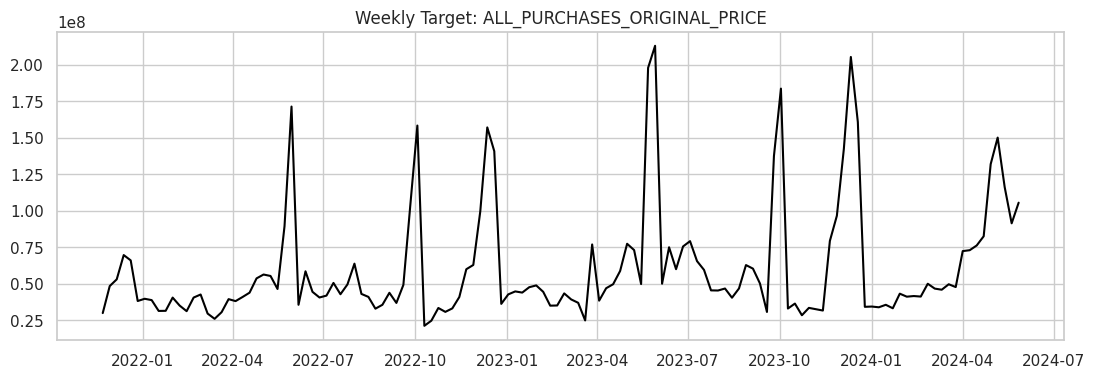

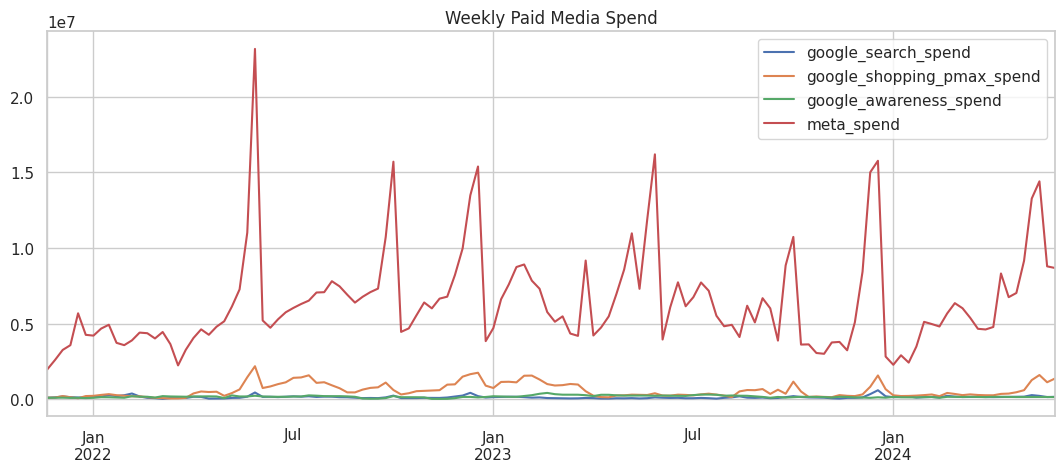

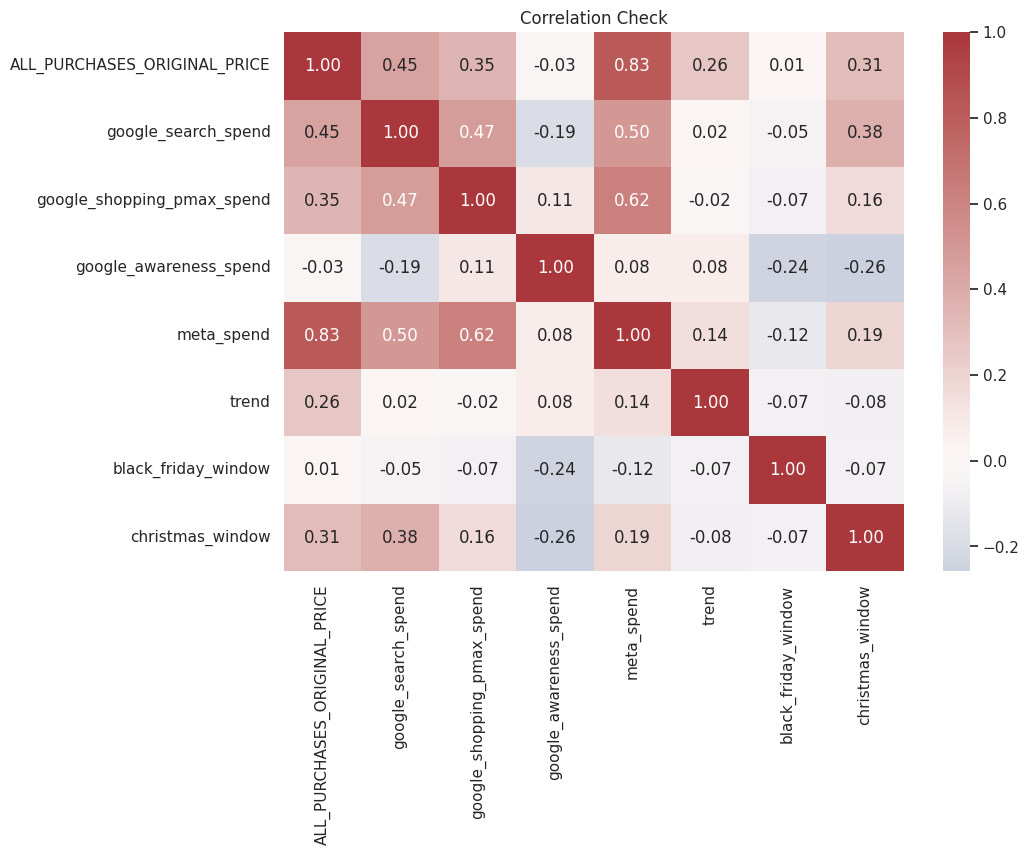

,sum,mean,median,max,spend_share
meta_spend,8.505428e+08,6.443506e+06,5678124.530,23170791.98,0.877817
google_shopping_pmax_spend,7.751833e+07,5.872600e+05,396535.305,2184416.15,0.080004
google_awareness_spend,2.282556e+07,1.729209e+05,160624.995,418862.49,0.023557
google_search_spend,1.804320e+07,1.366909e+05,122369.570,595247.59,0.018622


In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(data["week"], data[TARGET_COL], color="black")
ax.set_title(f"Weekly Target: {TARGET_COL}")
ax.set_xlabel("")
plt.show()

data.set_index("week")[channel_columns].plot(figsize=(13, 5), title="Weekly Paid Media Spend")
plt.xlabel("")
plt.show()

corr_cols = [TARGET_COL] + channel_columns + control_columns
plt.figure(figsize=(10, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Check")
plt.show()

spend_summary = data[channel_columns].agg(["sum", "mean", "median", "max"]).T
spend_summary["spend_share"] = spend_summary["sum"] / spend_summary["sum"].sum()
display(spend_summary.sort_values("sum", ascending=False))

## 6. Baseline And Seasonality EDA

STL decomposition gives a rough view of trend, seasonality, and noise. It is not pure natural demand because observed revenue includes marketing and other shocks.

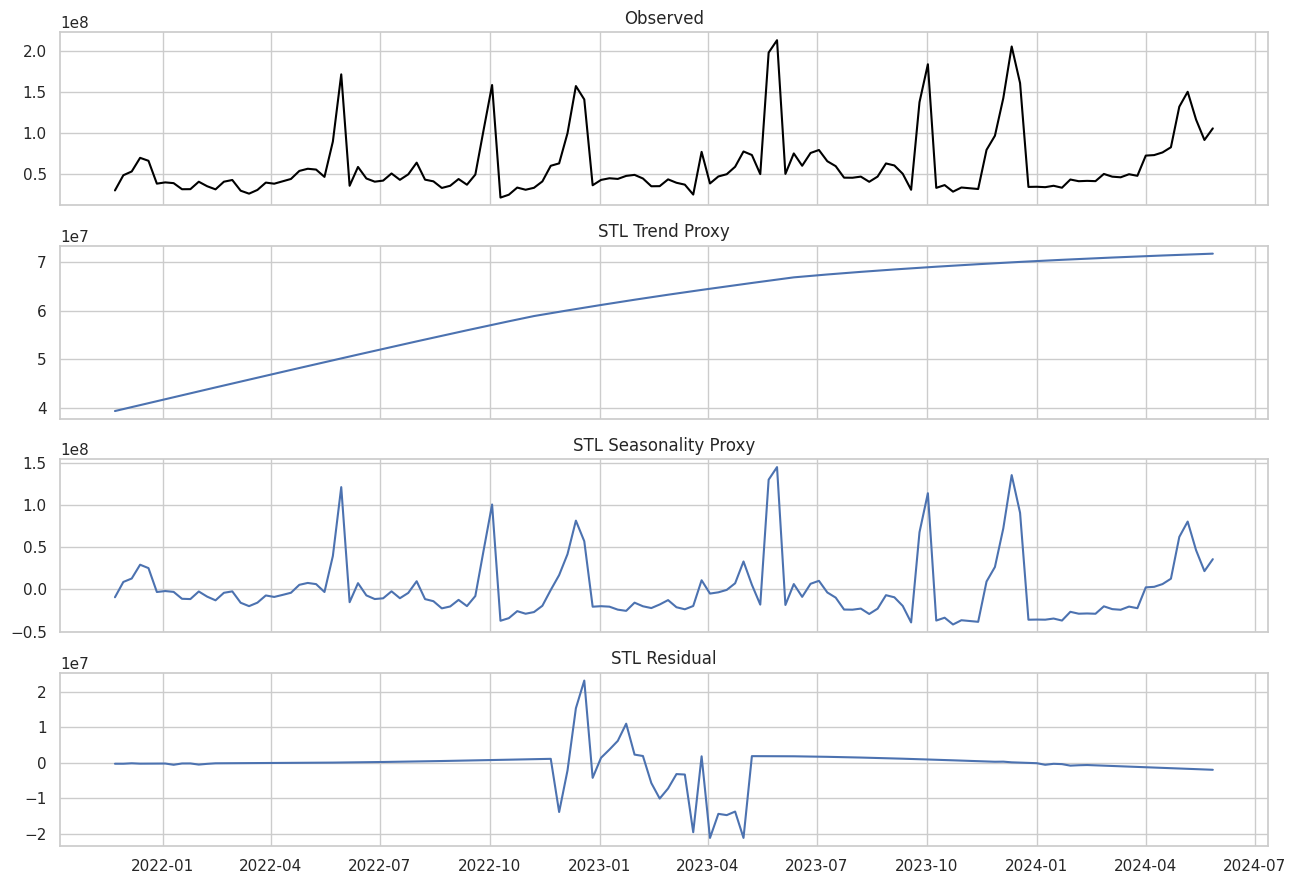

In [ ]:
from statsmodels.tsa.seasonal import STL

if len(data) >= 104:
    stl = STL(data[TARGET_COL], period=52, robust=True).fit()
    data["stl_trend"] = stl.trend
    data["stl_seasonal"] = stl.seasonal
    data["stl_resid"] = stl.resid

    fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
    axes[0].plot(data["week"], data[TARGET_COL], color="black"); axes[0].set_title("Observed")
    axes[1].plot(data["week"], data["stl_trend"]); axes[1].set_title("STL Trend Proxy")
    axes[2].plot(data["week"], data["stl_seasonal"]); axes[2].set_title("STL Seasonality Proxy")
    axes[3].plot(data["week"], data["stl_resid"]); axes[3].set_title("STL Residual")
    plt.tight_layout(); plt.show()
else:
    print("Less than 104 weekly rows; yearly STL seasonality is not reliable.")

## 7. Train/Test Split

The last 26 weeks are used as a holdout if available. If the selected series is shorter, this automatically uses a smaller holdout.

In [ ]:
TEST_WEEKS = min(26, max(8, len(data) // 5))
train = data.iloc[:-TEST_WEEKS].copy()
test = data.iloc[-TEST_WEEKS:].copy()

X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]
X_test = test.drop(columns=[TARGET_COL])
y_test = test[TARGET_COL]

print("Train:", train["week"].min(), "to", train["week"].max(), len(train))
print("Test:", test["week"].min(), "to", test["week"].max(), len(test))

Train: 2021-11-22 00:00:00 to 2023-11-27 00:00:00 106
Test: 2023-12-04 00:00:00 to 2024-05-27 00:00:00 26


## 8. Fit PyMC Marketing MMM

Start conservative: geometric adstock, logistic saturation, yearly seasonality 2. If you get divergences, increase `target_accept`, shorten `l_max`, group channels further, or add stronger priors.

In [ ]:
import arviz as az
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

mmm = MMM(
    date_column="week",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

idata = mmm.fit(
    X=X_train,
    y=y_train,
    draws=2000,
    tune=3000,
    chains=4,
    target_accept=0.97,
    random_seed=RANDOM_SEED,
)

Output()

ERROR:pymc.stats.convergence:There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

## 9. Diagnostics

Do this before interpreting contribution or ROAS. Watch `r_hat`, ESS, divergences, and trace plots.

['adstock_alpha', 'gamma_control', 'gamma_fourier', 'intercept', 'saturation_beta', 'saturation_lam', 'y_sigma', 'channel_contribution', 'channel_contribution_original_scale', 'control_contribution', 'control_contribution_original_scale', 'fourier_contribution', 'mu', 'total_contribution', 'total_contribution_original_scale', 'y_original_scale', 'yearly_seasonality_contribution', 'yearly_seasonality_contribution_original_scale']


,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
adstock_alpha[google_search_spend],0.164,0.146,0.000000e+00,3.720000e-01,0.001,0.002,7676.0,4049.0,1.0
adstock_alpha[google_shopping_pmax_spend],0.250,0.195,0.000000e+00,5.430000e-01,0.002,0.002,8389.0,3811.0,1.0
adstock_alpha[google_awareness_spend],0.252,0.196,0.000000e+00,5.420000e-01,0.002,0.002,7391.0,3850.0,1.0
adstock_alpha[meta_spend],0.029,0.027,0.000000e+00,6.600000e-02,0.000,0.000,6773.0,3125.0,1.0
gamma_control[trend],0.033,0.016,7.000000e-03,5.800000e-02,0.000,0.000,5410.0,4597.0,1.0
...,...,...,...,...,...,...,...,...,...
yearly_seasonality_contribution_original_scale[2023-10-30T00:00:00.000000000],3977644.667,5439147.214,-4.422806e+06,1.312762e+07,81293.868,64473.629,4589.0,4309.0,1.0
yearly_seasonality_contribution_original_scale[2023-11-06T00:00:00.000000000],3186453.409,5649873.138,-6.169438e+06,1.208411e+07,85733.641,66113.901,4434.0,4334.0,1.0
yearly_seasonality_contribution_original_scale[2023-11-13T00:00:00.000000000],1981915.649,5858369.505,-7.628057e+06,1.142142e+07,89192.617,67857.249,4384.0,4354.0,1.0
yearly_seasonality_contribution_original_scale[2023-11-20T00:00:00.000000000],424183.261,6042114.564,-9.944242e+06,9.856087e+06,91363.201,69224.247,4415.0,4271.0,1.0


,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


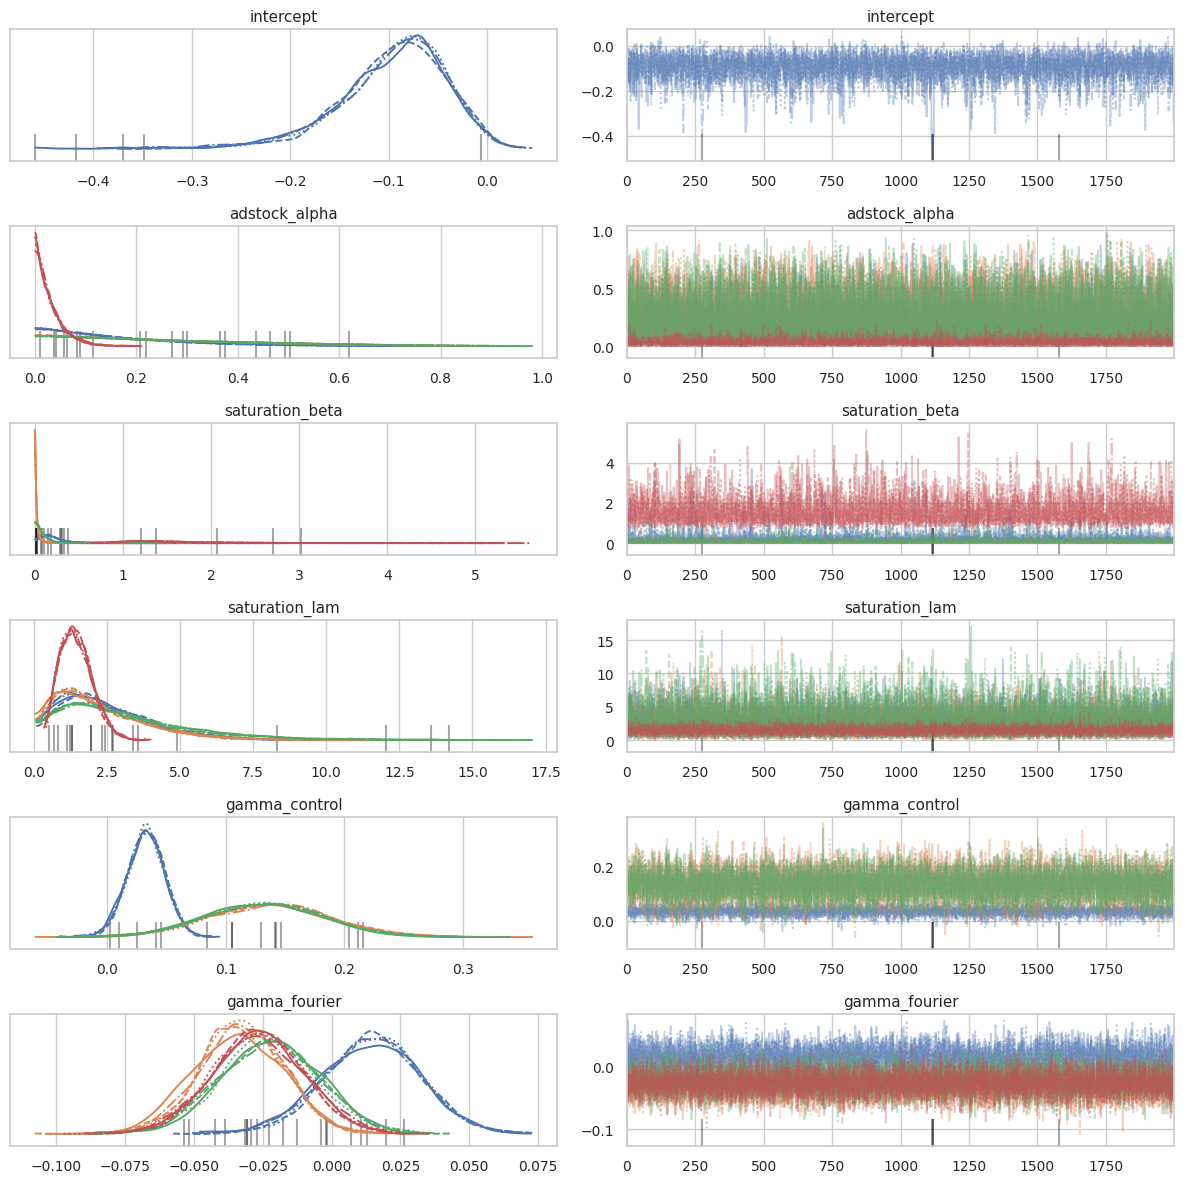

In [ ]:
print(list(idata.posterior.data_vars))
summary = az.summary(idata, hdi_prob=0.90)
display(summary)
display(summary[(summary["r_hat"] > 1.01) | (summary["ess_bulk"] < 200)])

vars_to_plot = [v for v in ["intercept", "beta_channel", "adstock_alpha", "saturation_beta", "saturation_lam", "gamma_control", "gamma_fourier"] if v in idata.posterior]
az.plot_trace(idata, var_names=vars_to_plot, compact=True)
plt.tight_layout(); plt.show()

## 10. Prediction Checks

Check posterior predictive fit and holdout performance. Good prediction is not proof of causal attribution, but bad prediction is a warning.

Output()

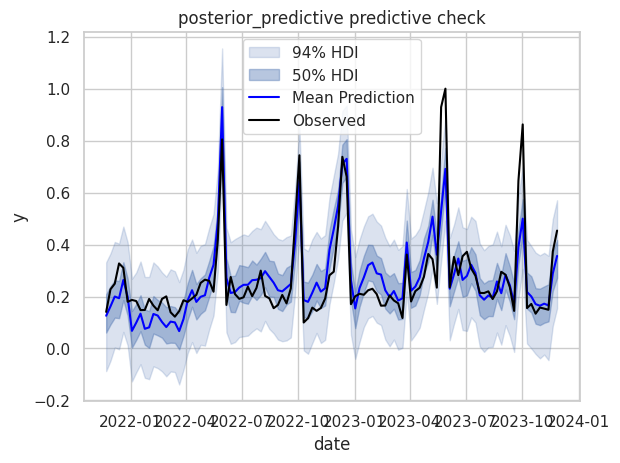

Output()

Holdout MAPE: 23.47%


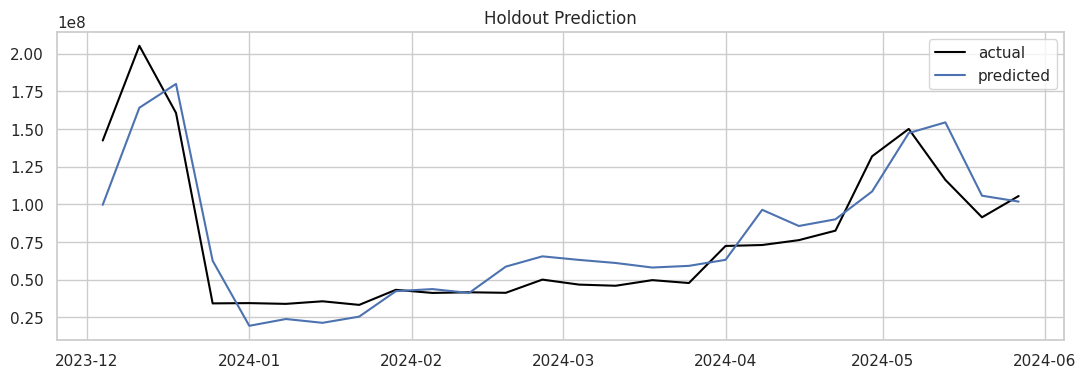

In [ ]:
try:
    mmm.sample_posterior_predictive(X_train)
    mmm.plot_posterior_predictive()
    plt.show()
except Exception as exc:
    print("Posterior predictive helper failed or is unavailable:", repr(exc))

try:
    pred_test = np.asarray(mmm.predict(X_test)).reshape(-1)
    mape = np.mean(np.abs((y_test.values - pred_test) / np.maximum(y_test.values, 1)))
    print(f"Holdout MAPE: {mape:.2%}")
    plt.figure(figsize=(13, 4))
    plt.plot(test["week"], y_test, label="actual", color="black")
    plt.plot(test["week"], pred_test, label="predicted")
    plt.title("Holdout Prediction")
    plt.legend(); plt.show()
except Exception as exc:
    print("Predict helper failed or is unavailable:", repr(exc))

## 11. Baseline, Seasonality, Contribution, And ROAS

Interpretation definitions:

- Strict baseline: intercept only.
- Natural baseline: intercept + trend + yearly seasonality.
- Non-media contribution: natural baseline + event controls.
- Media contribution: paid channel contribution after adstock and saturation.

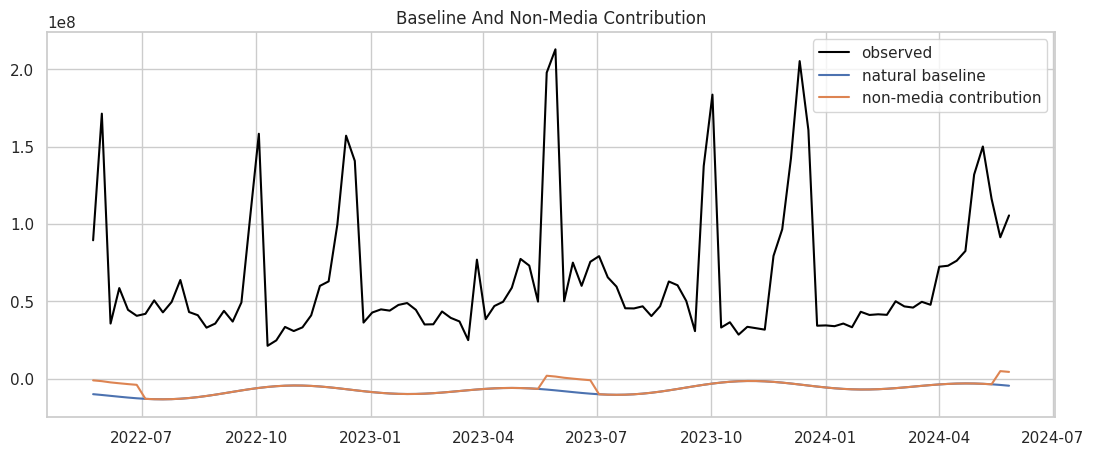

In [ ]:
contrib = mmm.compute_mean_contributions_over_time().copy()

# align dates
n = len(contrib)
data_plot = data.iloc[-n:].copy()
contrib["week"] = data_plot["week"].values

# rescale contributions back to original target scale
target_scale = data_plot[TARGET_COL].mean()

cols_to_rescale = [
    c for c in contrib.columns
    if c != "week"
]

contrib[cols_to_rescale] = contrib[cols_to_rescale] * target_scale

available_media_cols = [c for c in channel_columns if c in contrib.columns]

baseline_parts = [
    c for c in ["intercept", "trend", "yearly_seasonality"]
    if c in contrib.columns
]

event_parts = [
    c for c in ["black_friday_window", "christmas_window"]
    if c in contrib.columns
]

contrib["natural_baseline"] = contrib[baseline_parts].sum(axis=1)
contrib["non_media_contribution"] = contrib[baseline_parts + event_parts].sum(axis=1)
contrib["media_total"] = contrib[available_media_cols].sum(axis=1)
contrib["fitted_total"] = contrib["non_media_contribution"] + contrib["media_total"]

plt.figure(figsize=(13, 5))
plt.plot(data_plot["week"], data_plot[TARGET_COL], color="black", label="observed")
plt.plot(contrib["week"], contrib["natural_baseline"], label="natural baseline")
plt.plot(contrib["week"], contrib["non_media_contribution"], label="non-media contribution")
plt.title("Baseline And Non-Media Contribution")
plt.legend()
plt.show()

,spend,attributed_contribution,historical_roas,spend_share,contribution_share
google_search_spend,1.804320e+07,3.615287e+08,20.036843,0.018622,0.146274
google_awareness_spend,2.282556e+07,2.583569e+08,11.318755,0.023557,0.104531
meta_spend,8.505428e+08,1.822943e+09,2.143271,0.877817,0.737561
google_shopping_pmax_spend,7.751833e+07,2.875288e+07,0.370917,0.080004,0.011633


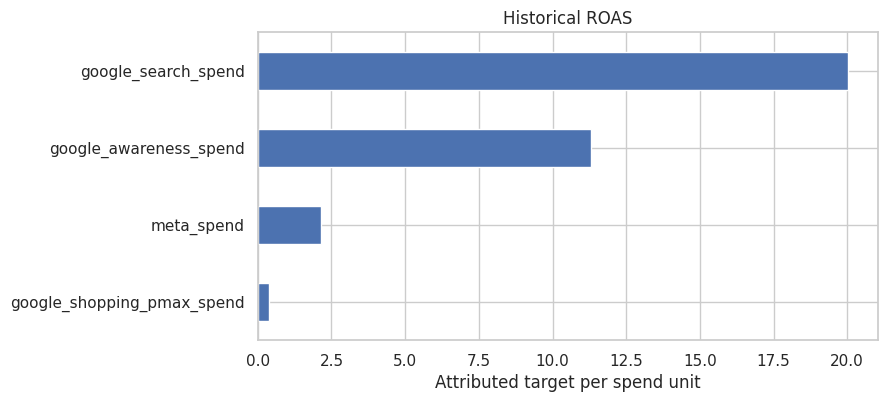

In [ ]:
contribution_total = contrib[available_media_cols].sum().rename("attributed_contribution")
spend_total = data[channel_columns].sum().rename("spend")
roas = pd.concat([spend_total, contribution_total], axis=1)
roas["historical_roas"] = roas["attributed_contribution"] / roas["spend"].replace(0, np.nan)
roas["spend_share"] = roas["spend"] / roas["spend"].sum()
roas["contribution_share"] = roas["attributed_contribution"] / roas["attributed_contribution"].sum()
display(roas.sort_values("historical_roas", ascending=False))

roas.sort_values("historical_roas")["historical_roas"].plot.barh(figsize=(8, 4), title="Historical ROAS")
plt.xlabel("Attributed target per spend unit")
plt.show()

## 12. Response Curves And Stakeholder Advice

Use response curves and uncertainty for recommendations. Do not recommend budget changes from historical ROAS alone.

Using plot_direct_contribution_curves


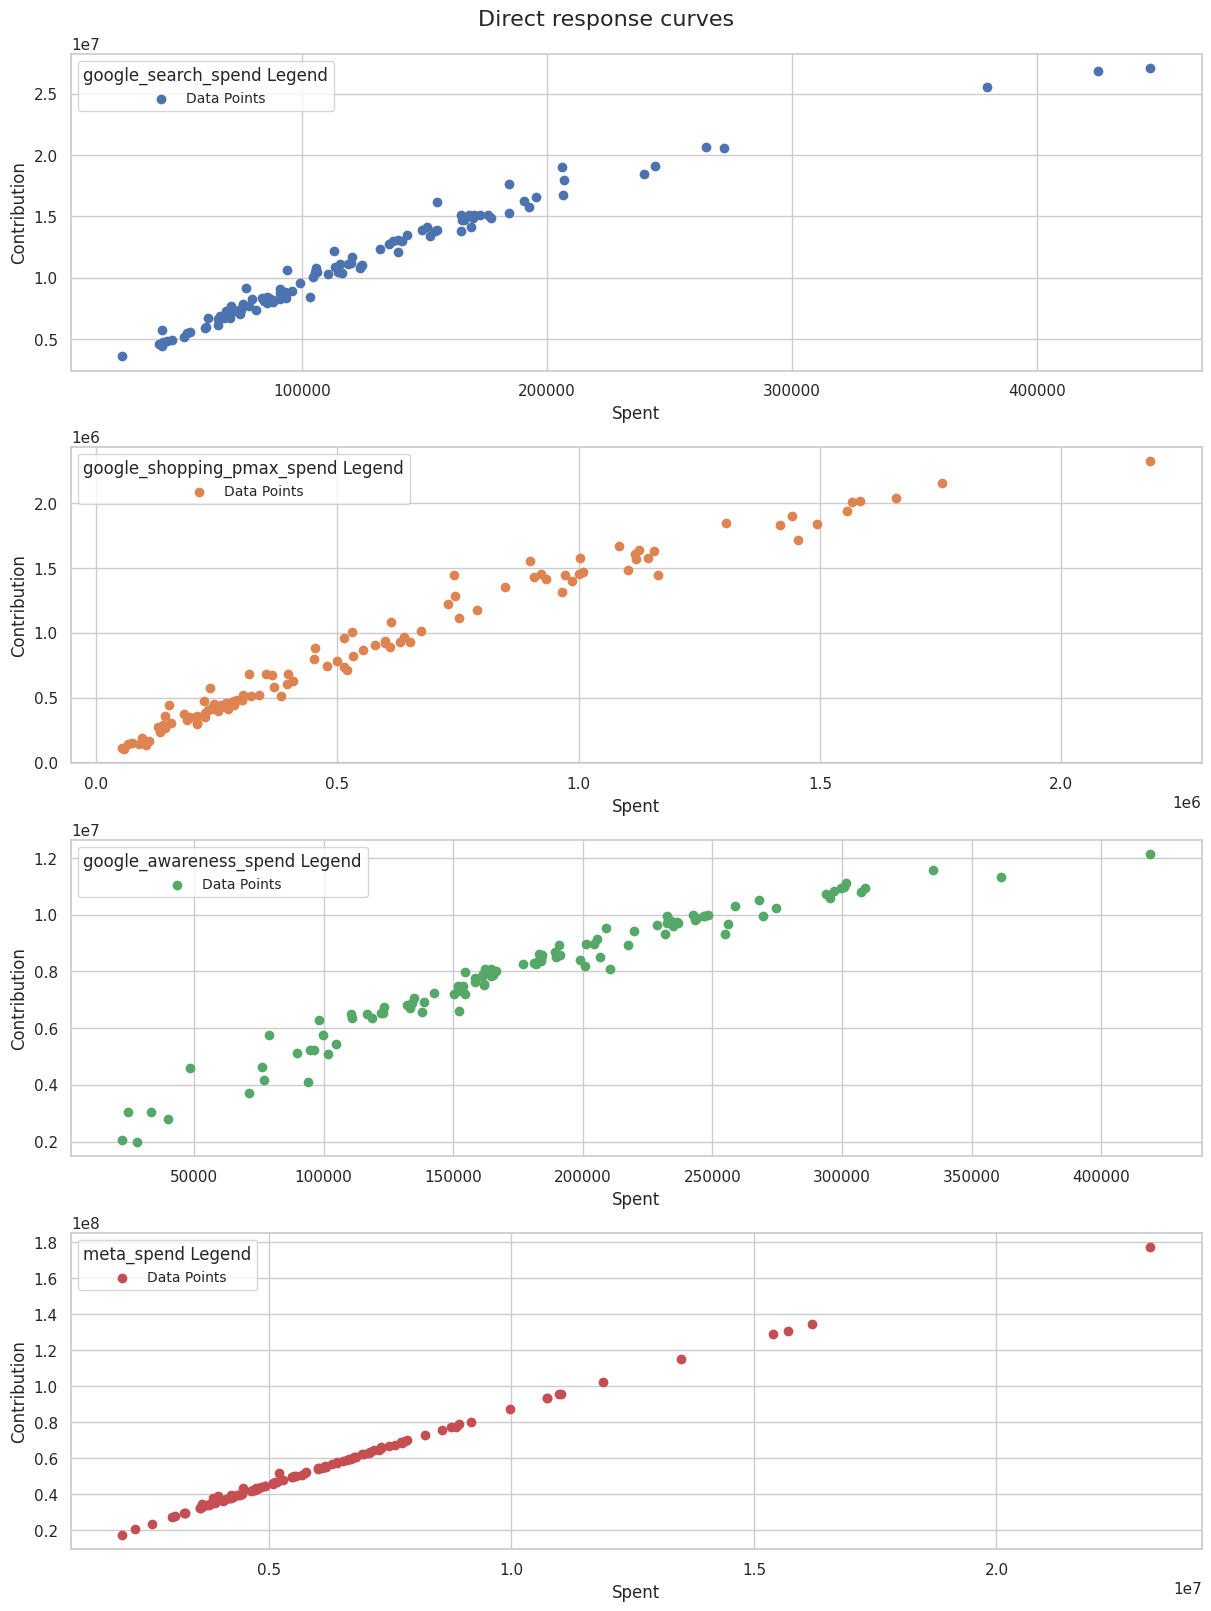

In [ ]:
for method_name in ["plot_direct_contribution_curves", "plot_channel_contribution_grid", "plot_response_curves"]:
    if hasattr(mmm, method_name):
        try:
            print("Using", method_name)
            getattr(mmm, method_name)()
            plt.show()
            break
        except Exception as exc:
            print(method_name, "failed:", repr(exc))
else:
    print("No response-curve helper found in this pymc-marketing version.")

## 13. Stakeholder Summary Template

Use this only after diagnostics are acceptable.

1. **Scope:** We modeled weekly revenue for one selected time series using grouped paid media spend, trend, peak-season controls, and yearly seasonality.
2. **Baseline:** Natural baseline is intercept + trend + seasonality. It reflects non-paid-media demand patterns, not a perfect causal truth.
3. **Media:** Paid media contribution is incremental revenue attributed after accounting for carryover and diminishing returns.
4. **Uncertainty:** Report credible intervals and diagnostics. If adstock/saturation are unstable, be cautious with precise budget recommendations.
5. **Action:** Recommend small budget shifts based on marginal returns and saturation curves, then validate with lift tests or holdouts.